In [2]:
# Import libraries
import pandas as p
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report, mean_squared_error, mean_absolute_error
from mask2bbox import BBoxes
from skimage.io import imread

micronuclei
0    1122
1      18
Name: count, dtype: int64


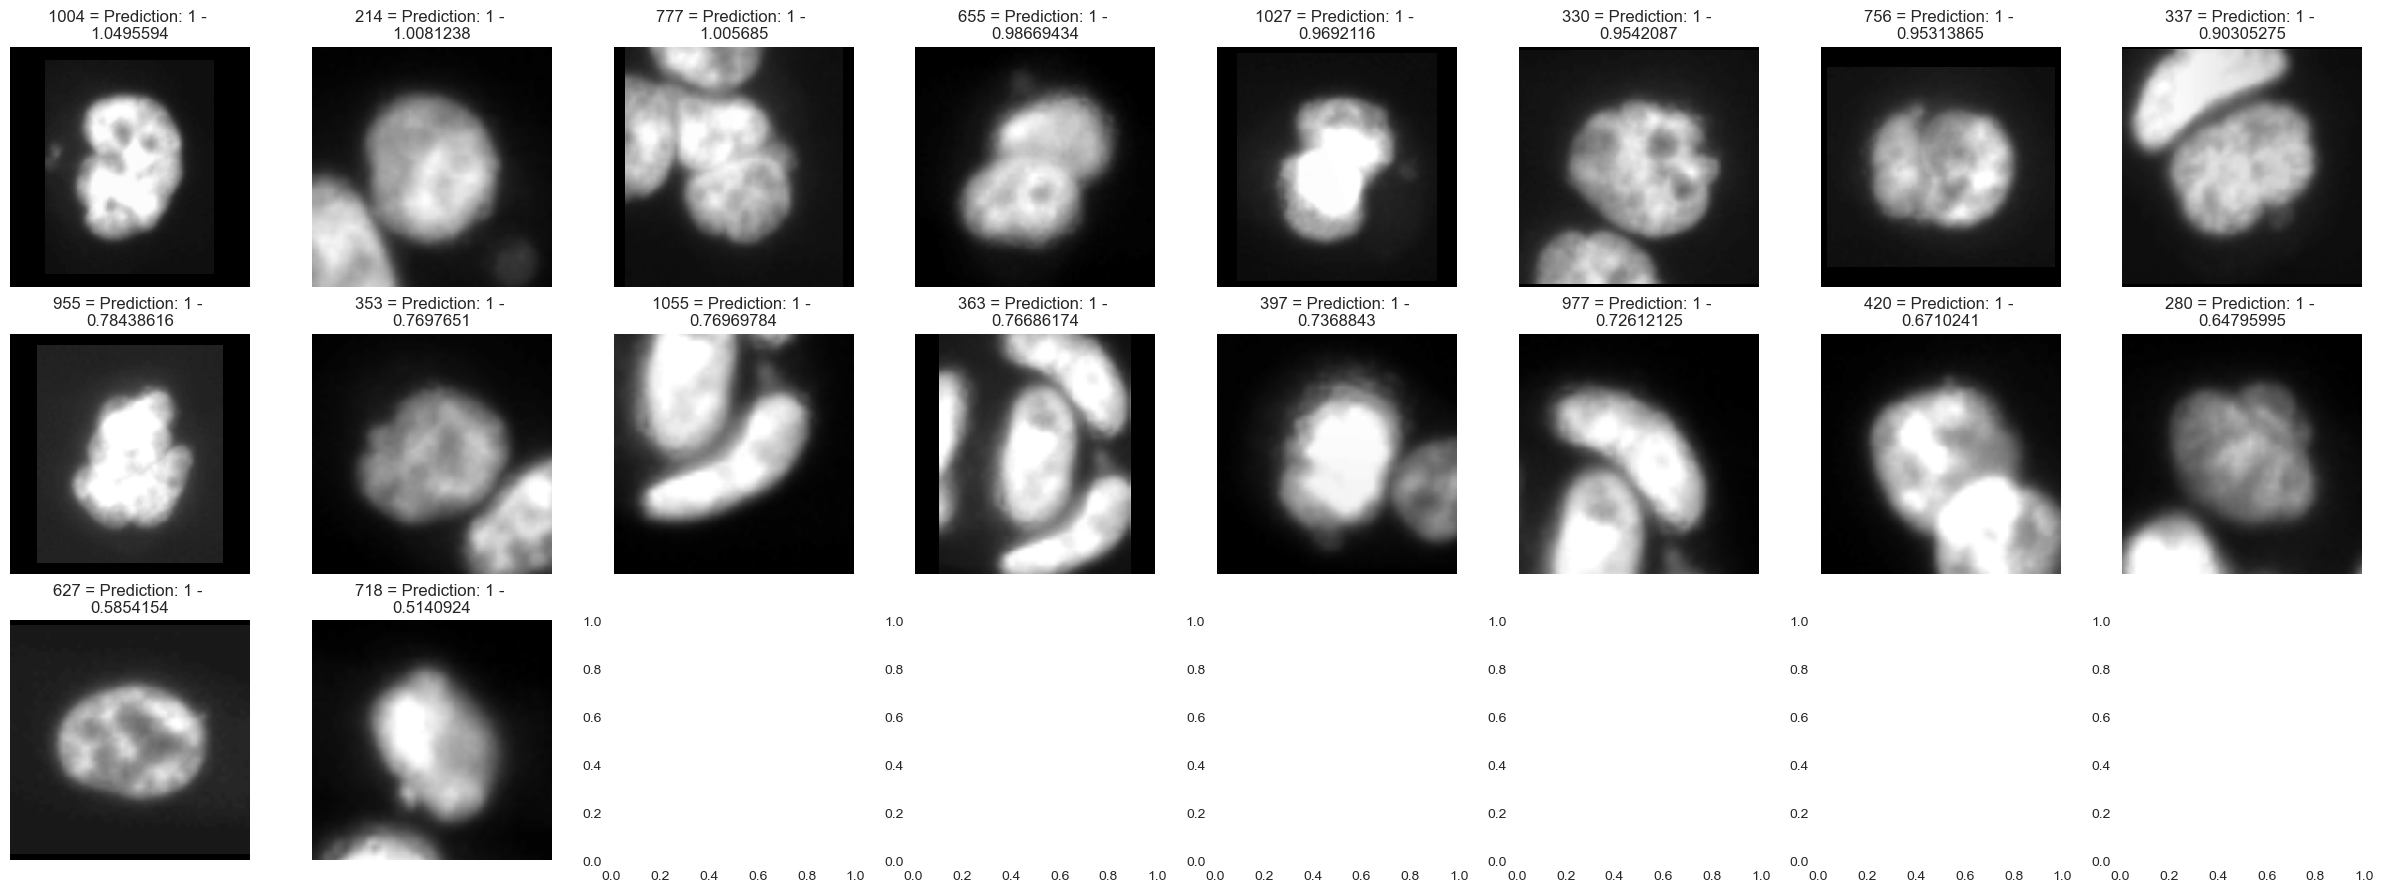

In [23]:
size = (256, 256)
root = "/Users/miguelibarra/PycharmProjects/cin/data"
filename="24h_combined_071023-01-Stitching-03_s02"
# filename="s01_patch_9"

prediction_df = pd.read_csv(f"{root}/Lindsay/H358_24h/predictions/revisions/{filename}_predictions.csv")
boxes = BBoxes.from_mask(f"{root}/Lindsay/H358_24h/segmentation/stardist/{filename}.tif")
boxes.image = f"{root}/Lindsay/H358_24h/ometif/{filename}.ome.tif"

rf = boxes.calculate_resizing_factor(0.6, size)
boxes = boxes.expand(15)

def plot_crop_grid(data, cols=8, cmap="turbo"):
    # Estimate the number of rows needed for the plot
    rows = len(data)//cols if len(data)%cols==0 else len(data)//cols+1

    # Plot
    sns.set_style("white")
    fig, ax = plt.subplots(rows, cols, figsize=(3*cols, 3*rows), )
    for i,(ix, j) in enumerate(data.iterrows()):
        cell_id = int(j.CellID)-1
        ax[ i//cols, i%cols].matshow(boxes.grab_pixels_from(cell_id, "image",  rf[cell_id], size, rescale_intensity=False), cmap=cmap)
        ax[ i//cols, i%cols].set_title(f"{int(j.CellID)} = Prediction: {j['micronuclei']:.0f} - \n{j['score']}")
        ax[ i//cols, i%cols].set_yticks([])
        ax[ i//cols, i%cols].set_xticks([])

    sns.despine(left=True, bottom=True)
    fig.tight_layout()

# print(prediction_df.shape)

print(prediction_df["micronuclei"].value_counts())

# sns.set_style("white")
# sns.countplot(data=prediction_df, x="micronuclei")

plot_crop_grid(prediction_df[prediction_df["micronuclei"]==1].sort_values("score", ascending=False), cols=8, cmap="gray")

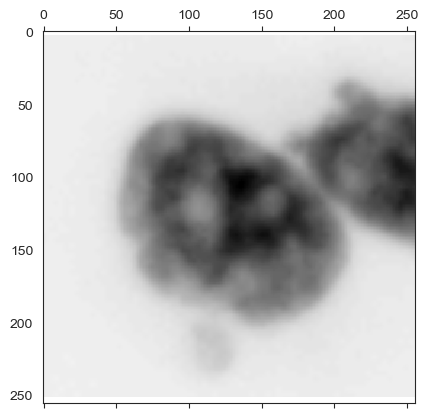

In [21]:
plt.matshow(boxes.grab_pixels_from(1068, "image",  rf[1068], size, rescale_intensity=False), cmap="gray_r")    